In [1]:
import boto3
from os import environ
from IPython.display import Image, display

In [2]:
session = boto3.Session(profile_name="isengard_account")
creds = session.get_credentials()
creds = creds.get_frozen_credentials()

## set the appropiate environment variables
environ['AWS_ACCESS_KEY_ID'] = creds.access_key
environ['AWS_SECRET_ACCESS_KEY'] = creds.secret_key
environ['AWS_SESSION_TOKEN'] = creds.token

In [3]:
sts_client = session.client("sts")
sagemaker_client = session.client("sagemaker")
s3_client = session.client("s3")
sagemaker_runtime = session.client("sagemaker-runtime")


acc_id = sts_client.get_caller_identity()["Account"]
acc_region = sts_client.meta.region_name

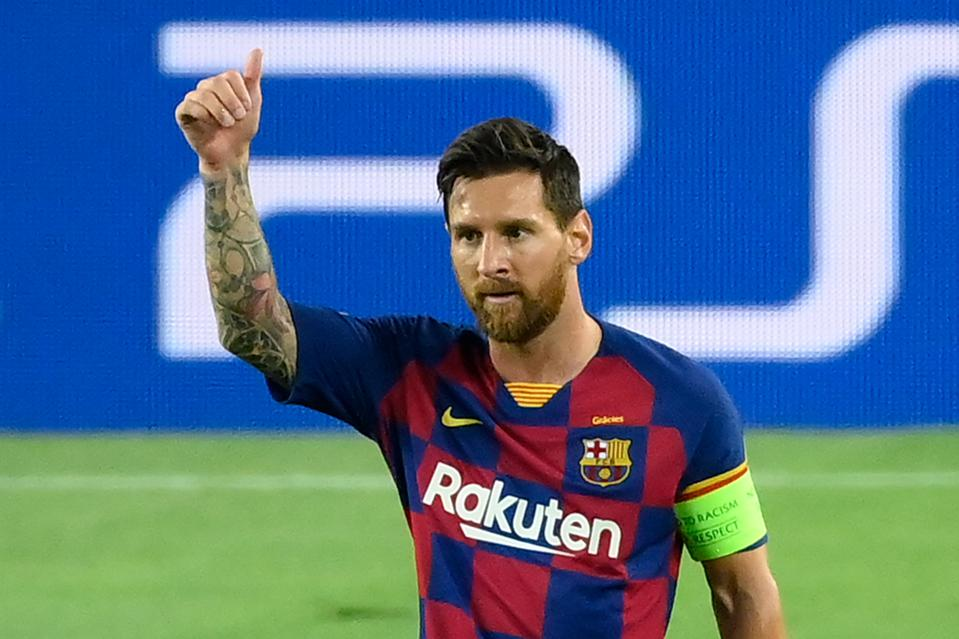

In [4]:
bucket_name = f"cdk-sagemaker-data-{acc_id}-{acc_region}"
model_bucket = f"cdk-sagemaker-models-{acc_id}-{acc_region}"

s3_bucket = session.resource("s3").Bucket(bucket_name)
s3_model_bucket = session.resource("s3").Bucket(model_bucket)

image_key = "pytorch/lionel_messi.jpg"

model_key = "pytorch_yolo.tar.gz"

model_data_url = f"s3://{model_bucket}/{model_key}"


retrieved_image = s3_bucket.Object(image_key).get()
image_bytes = retrieved_image["Body"].read()

# display image first

display(Image(image_bytes))

local files

sagemaker

In [15]:
sagemaker_endpoints = sagemaker_client.list_endpoints()["Endpoints"]

endpoint = "PytorchPersonDetectionEndpoint"
for endpoint in sagemaker_endpoints:
    if isinstance(endpoint,str) and endpoint in endpoint["EndpointName"]:
        endpoint = endpoint["EndpointName"]

endpoint_arn = endpoint["EndpointArn"]
endpoint_name = endpoint["EndpointName"]
endpoint_name

'PytorchPersonDetectionEndpoint'

In [18]:
response = sagemaker_runtime.invoke_endpoint(
    EndpointName=endpoint_name, ContentType="image/jpeg", Body=image_bytes, Accept="application/x-image"
)

response

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:1                                                                                    │
│                                                                                                  │
│ ❱ 1 response = sagemaker_runtime.invoke_endpoint(                                                │
│   2 │   EndpointName=endpoint_name, ContentType="image/jpeg", Body=image_bytes, Accept="appl     │
│   3 )                                                                                            │
│   4                                                                                              │
│                                                                                                  │
│ /Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/botocore/client.py:570  │
│ in _api_call                                                                                     │
│                                                                                                  │
│    567 │   │   │   │   │   f"{py_operation_name}() only accepts keyword arguments."              │
│    568 │   │   │   │   )                                                                         │
│    569 │   │   │   # The "self" in this scope is referring to the BaseClient.                    │
│ ❱  570 │   │   │   return self._make_api_call(operation_name, kwargs)                            │
│    571 │   │                                                                                     │
│    572 │   │   _api_call.__name__ = str(py_operation_name)                                       │
│    573                                                                                           │
│                                                                                                  │
│ /Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/botocore/context.py:124 │
│ in wrapper                                                                                       │
│                                                                                                  │
│   121 │   │   │   with start_as_current_context():                                               │
│   122 │   │   │   │   if hook:                                                                   │
│   123 │   │   │   │   │   hook()                                                                 │
│ ❱ 124 │   │   │   │   return func(*args, **kwargs)                                               │
│   125 │   │                                                                                      │
│   126 │   │   return wrapper                                                                     │
│   127                                                                                            │
│                                                                                                  │
│ /Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/botocore/client.py:1031 │
│ in _make_api_call                                                                                │
│                                                                                                  │
│   1028 │   │   │   │   "Code"                                                                    │
│   1029 │   │   │   )                                                                             │
│   1030 │   │   │   error_class = self.exceptions.from_code(error_code)                           │
│ ❱ 1031 │   │   │   raise error_class(parsed_response, operation_name)                            │
│   1032 │   │   else:                                                                             │
│   1033 │   │   │   return parsed_response                                                        │
│   1034                                                     

In [12]:
# locally deploy as a sagemaker endpoint

import sagemaker
from sagemaker.pytorch import PyTorchModel
import boto3
from os import environ
from pathlib import Path

session = boto3.Session(profile_name="isengard_account")
creds = session.get_credentials()
creds = creds.get_frozen_credentials()

## set the appropiate environment variables
environ["AWS_ACCESS_KEY_ID"] = creds.access_key
environ["AWS_SECRET_ACCESS_KEY"] = creds.secret_key
environ["AWS_SESSION_TOKEN"] = creds.token

sagemaker_session = sagemaker.LocalSession(boto_session=session)
sagemaker_session.config = {"local": {"local_code": True}}

role = session.client("iam").get_role(RoleName="AWSPowerUser")["Role"]["Arn"]

model_path = Path(
    "../models/pytorch_yolo/pytorch_yolo.tar.gz"
)

model = PyTorchModel(
    entry_point="inference.py",
    role=role,
    framework_version="2.6.0",
    py_version="py312",
    model_data=str(model_path),
)

predictor = model.deploy(
    initial_instance_count=1,
    instance_type="local",
    endpoint_name="sagemaker-endpoint",
)


/Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/pydantic/_internal/_fields.py:198: UserWarning: Field name "json" in "MonitoringDatasetFormat" shadows an attribute in parent "Base"
  warnings.warn(


[04/10/25 15:48:41] INFO     Found credentials in environment variables.                        ]8;id=676363;file:///Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=949954;file:///Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/botocore/credentials.py#1213\1213]8;;\

sagemaker.config INFO - Not applying SDK defaults from location: /Library/Application Support/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /Users/cerozob/Library/Application Support/sagemaker/config.yaml


[04/10/25 15:48:42] INFO     Found credentials in environment variables.                        ]8;id=7413;file:///Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=995581;file:///Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/botocore/credentials.py#1213\1213]8;;\

[04/10/25 15:48:44] INFO     Repacking model artifact (../models/pytorch_yolo/pytorch_yolo.tar.gz),    ]8;id=234438;file:///Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/sagemaker/model.py\model.py]8;;\:]8;id=968341;file:///Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/sagemaker/model.py#820\820]8;;\
                             script artifact (None), and dependencies ([]) into single tar.gz file                 
                             located at                                                                            
                             s3://sagemaker-us-east-1-711387129682/pytorch-inference-2025-04-10-20-48-             
                             43-053/model.tar.gz. This may take some time depending on model size...               

...

                    WARNING  Retrying (Retry(total=0, connect=None, read=None, redirect=None, ]8;id=687602;file:///Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/urllib3/connectionpool.py\connectionpool.py]8;;\:]8;id=287841;file:///Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/urllib3/connectionpool.py#868\868]8;;\
                             status=None)) after connection broken by                                              
                             'ConnectionResetError(54, 'Connection reset by peer')': /ping                         

                    INFO     Container still not up, got: -1                                        ]8;id=67500;file:///Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/sagemaker/local/entities.py\entities.py]8;;\:]8;id=261292;file:///Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/sagemaker/local/entities.py#998\998]8;;\

hoc5isl057-algo-1-snq64  | nvidia-smi not available or failed: Cannot run program "nvidia-smi": error=2, No such file or directory
hoc5isl057-algo-1-snq64  | 2025-04-10T20:50:52,070 [WARN ] main org.pytorch.serve.util.ConfigManager - Your torchserve instance can access any URL to load models. When deploying to production, make sure to limit the set of allowed_urls in config.properties
hoc5isl057-algo-1-snq64  | 2025-04-10T20:50:52,096 [INFO ] main org.pytorch.serve.servingsdk.impl.PluginsManager - Initializing plugins manager...
hoc5isl057-algo-1-snq64  | 2025-04-10T20:50:52,271 [INFO ] main org.pytorch.serve.metrics.configuration.MetricConfiguration - Successfully loaded metrics configuration from /usr/local/lib/python3.12/site-packages/ts/configs/metrics.yaml
hoc5isl057-algo-1-snq64  | 2025-04-10T20:50:52,394 [INFO ] main org.pytorch.serve.ModelServer - 
hoc5isl057-algo-1-snq64  | Torchserve version: 0.12.0
hoc5isl057-algo-1-snq64  | TS Home: /usr/local/lib/python3.12/site-packages
h

[04/10/25 15:50:56] INFO     Checking if serving container is up, attempt: 20                       ]8;id=735197;file:///Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/sagemaker/local/entities.py\entities.py]8;;\:]8;id=101655;file:///Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/sagemaker/local/entities.py#995\995]8;;\

hoc5isl057-algo-1-snq64  | 2025-04-10T20:50:56,391 [INFO ] W-9006-model_1.0-stdout MODEL_LOG - s_name_part0=/tmp/.ts.sock, s_name_part1=9006, pid=71
hoc5isl057-algo-1-snq64  | 2025-04-10T20:50:56,393 [INFO ] W-9000-model_1.0-stdout MODEL_LOG - s_name_part0=/tmp/.ts.sock, s_name_part1=9000, pid=70
hoc5isl057-algo-1-snq64  | 2025-04-10T20:50:56,422 [INFO ] W-9002-model_1.0-stdout MODEL_LOG - s_name_part0=/tmp/.ts.sock, s_name_part1=9002, pid=72
hoc5isl057-algo-1-snq64  | 2025-04-10T20:50:56,392 [INFO ] W-9001-model_1.0-stdout MODEL_LOG - s_name_part0=/tmp/.ts.sock, s_name_part1=9001, pid=69
hoc5isl057-algo-1-snq64  | 2025-04-10T20:50:56,434 [INFO ] W-9006-model_1.0-stdout MODEL_LOG - Listening on port: /tmp/.ts.sock.9006
hoc5isl057-algo-1-snq64  | 2025-04-10T20:50:56,434 [INFO ] W-9000-model_1.0-stdout MODEL_LOG - Listening on port: /tmp/.ts.sock.9000
hoc5isl057-algo-1-snq64  | 2025-04-10T20:50:56,435 [INFO ] W-9000-model_1.0-stdout MODEL_LOG - Successfully loaded /usr/local/lib/python3.

In [ ]:
from sagemaker.serializers import DataSerializer

ds = DataSerializer(content_type="application/x-image")

# predict on the endpoint
with open("lionel_messi.jpg", "rb") as file:
    img = file.read()
    ser = ds.serialize(img)


response = predictor.predict(
    img, {"ContentType": "application/x-image", "Accept": "application/x-image"}
)
response

hoc5isl057-algo-1-snq64  | 2025-04-10T20:55:17,217 [INFO ] epollEventLoopGroup-3-3 TS_METRICS - ts_inference_requests_total.Count:1.0|#model_name:model,model_version:default|#hostname:8a66fce80440,timestamp:1744318517
hoc5isl057-algo-1-snq64  | 2025-04-10T20:55:17,223 [INFO ] W-9006-model_1.0 org.pytorch.serve.wlm.WorkerThread - Looping backend response at: 1744318517223
hoc5isl057-algo-1-snq64  | 2025-04-10T20:55:17,247 [INFO ] W-9006-model_1.0-stdout MODEL_LOG - Backend received inference at: 1744318517
hoc5isl057-algo-1-snq64  | 2025-04-10T20:55:17,248 [INFO ] W-9006-model_1.0-stdout MODEL_LOG - [INFO] input_fn-thread id: MainThread
hoc5isl057-algo-1-snq64  | 2025-04-10T20:55:17,248 [INFO ] W-9006-model_1.0-stdout MODEL_LOG - [INFO] input_fn-process id: 71
hoc5isl057-algo-1-snq64  | 2025-04-10T20:55:17,248 [INFO ] W-9006-model_1.0-stdout MODEL_LOG - [INFO] input_fn-content_type: application/x-image
hoc5isl057-algo-1-snq64  | 2025-04-10T20:55:17,292 [INFO ] W-9006-model_1.0 org.pytor

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:11                                                                                   │
│                                                                                                  │
│    8 │   ser = ds.serialize(img)                                                                 │
│    9                                                                                             │
│   10                                                                                             │
│ ❱ 11 response = predictor.predict(                                                               │
│   12 │   img, {"ContentType": "application/x-image", "Accept": "application/x-image"}            │
│   13 )                                                                                           │
│   14 response                                                                                    │
│                                                                                                  │
│ /Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/sagemaker/base_predicto │
│ r.py:213 in predict                                                                              │
│                                                                                                  │
│   210 │   │   │   request_args["InferenceComponentName"] = inference_component_name              │
│   211 │   │                                                                                      │
│   212 │   │   response = self.sagemaker_session.sagemaker_runtime_client.invoke_endpoint(**req   │
│ ❱ 213 │   │   return self._handle_response(response)                                             │
│   214 │                                                                                          │
│   215 │   def _handle_response(self, response):                                                  │
│   216 │   │   """Placeholder docstring"""                                                        │
│                                                                                                  │
│ /Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/sagemaker/base_predicto │
│ r.py:219 in _handle_response                                                                     │
│                                                                                                  │
│   216 │   │   """Placeholder docstring"""                                                        │
│   217 │   │   response_body = response["Body"]                                                   │
│   218 │   │   content_type = response.get("ContentType", "application/octet-stream")             │
│ ❱ 219 │   │   return self.deserializer.deserialize(response_body, content_type)                  │
│   220 │                                                                                          │
│   221 │   def _create_request_args(                                                              │
│   222 │   │   self,                                                                              │
│                                                                                                  │
│ /Users/cerozob/Desktop/MAIA-Sagemaker/.venv/lib/python3.12/site-packages/sagemaker/base_deserial │
│ izers.py:251 in deserialize                                                                      │
│                                                                                                  │
│   248 │   │   finally:                                                                           │
│   249 │   │   │   stream.close()                                                                 │
│   250 │   │                                                                                      │
│ ❱ 251 │   │   raise ValueError("%s cannot read content type